# Análisis predictivo de datos - Evaluación 1


**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y comprensión de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo de datos.

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

#### <span style="color:green"> Cargar pandas en el arrchivo de datos

In [1]:
from pathlib import Path

import pandas as pd
    
ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'athlete_events.csv' 

df = pd.read_csv(DATA_DIR / file_path, na_values=[' ?', ' '])
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


#### <span style="color:green"> Ver cuantas variables y registros tiene el database

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


#### <span style="color:green"> Estadisticas descriptivas para Categoricas y numericas

In [3]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [4]:
df.describe(include='object').T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


#### <span style="color:green"> Identificacion de valores duplicados

In [5]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  1385


#### <span style="color:green"> Identificacion de valores nulos

In [6]:
df.isnull().sum().sort_values(ascending=False).head(5)

Medal     231333
Weight     62875
Height     60171
Age         9474
Sex            0
dtype: int64

#### <span style="color:green">Analizando la estructura del dataset, se puede observar que las columnas "Age" y "Height" son numéricas tipo int, no tipo float, panda lo detecta si por los valores nulos, asi que hay que gestionar los datos nulos para cambiarlos, lo hare mas adelante en el campo que pide gestionar estos.

#### <span style="color:green"> El database tiene 15 variables y 217116

#### <span style="color:green"> El database tiene 1385 valores duplicados

#### <span style="color:green"> Hay 4 variables con valores nulos, Medal, Weight, Height y Age

## Descarte las variables que considere irrelevantes para su modelo (p.e. claves primarias, variables con valores únicos, variables redundantes, entre otros).

#### <span style="color:green"> ID Es clave primaria
#### <span style="color:green"> Games es rebundante ya que dice lo mismo que Year y Season juntos
#### <span style="color:green"> Name tiene muchos valores unicos

#### <span style="color:green"> NOC tiene en su gran mayoria lo mismo que Team (el pais) asi que en general es rebundante

#### <span style="color:green"> Con esto identificado vamos a descartar estas variables



In [7]:
df = df.drop(columns=['ID', 'Games','Name','NOC'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     271116 non-null  object 
 1   Age     261642 non-null  float64
 2   Height  210945 non-null  float64
 3   Weight  208241 non-null  float64
 4   Team    271116 non-null  object 
 5   Year    271116 non-null  int64  
 6   Season  271116 non-null  object 
 7   City    271116 non-null  object 
 8   Sport   271116 non-null  object 
 9   Event   271116 non-null  object 
 10  Medal   39783 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 22.8+ MB


## Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

#### <span style="color:green"> Gestionar datos duplicados

In [8]:
df = df.drop_duplicates()

In [9]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


#### <span style="color:green"> Gestiono los datos nulos (lo cual como dije en el anterior punto hara posible cambiar al formato correcto a Age y Height que no son float, si no, int)

In [10]:
df[['Medal', 'Weight', 'Height', 'Age']].isnull().sum()*100/df.shape[0]

Medal     85.255838
Weight    20.001770
Height    18.962717
Age        1.991903
dtype: float64

#### <span style="color:green"> Caso variable Medal

In [11]:
df['Medal'].fillna(value='No medal').loc[1:6]

1    No medal
2    No medal
3        Gold
4    No medal
5    No medal
6    No medal
Name: Medal, dtype: object

#### <span style="color:green"> Caso variable Height, la imputo con un promedio segun el deporte ya que un valor nulo de por ejemplo alguien de basketball es diferente a uno de gimnasta (basketball suelen ser mas altos)

In [12]:
df['Height'] = df.groupby('Sport')['Height'].transform(lambda x: x.fillna(x.mean()))

df.loc[1:6, 'Height']

1    170.000000
2    175.405423
3    182.480000
4    185.000000
5    185.000000
6    185.000000
Name: Height, dtype: float64

#### <span style="color:green"> Los otros los elimino ya que no afectan en gran medida al ser pocos valores nulos en porcentaje  (Tambien vuelvo a poner Height en quitar nulos ya que si un deporte tiene todos sus registros de altura como nulos, x.mean() devuelve NaN, y la columna seguiria teniendo nulos.

In [13]:
df= df.dropna(subset=['Weight', 'Age', 'Height' ])

#### <span style="color:green"> Ya con esto puedo terminar de arreglar las variables, Height y Age como mencione son numericas tipo int, no float, asi que ya sin tener valores nulos, las puedo cambiar.

In [14]:
df['Age'] = df['Age'].astype(int)
df['Height'] = df['Height'].astype(int)

#### <span style="color:green">  Muestro que cambie efectivamente los tipos de Age y Height a int en lugar de float

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207026 entries, 0 to 271115
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     207026 non-null  object 
 1   Age     207026 non-null  int64  
 2   Height  207026 non-null  int64  
 3   Weight  207026 non-null  float64
 4   Team    207026 non-null  object 
 5   Year    207026 non-null  int64  
 6   Season  207026 non-null  object 
 7   City    207026 non-null  object 
 8   Sport   207026 non-null  object 
 9   Event   207026 non-null  object 
 10  Medal   30374 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 19.0+ MB


## Análisis exploratorio de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.
- Indiquen qué tipo de procesamiento debería recibir cada una de las variables categóricas, según su tipo y cardinalidad.

Reporte los resultados del análisis en una celda de texto.

In [16]:
df.describe(include='object').T

,count,unique,top,freq
Sex,207026,2,M,140350
Team,207026,680,United States,13725
Season,207026,2,Summer,167584
City,207026,42,London,13996
Sport,207026,56,Athletics,32387
Event,207026,594,Ice Hockey Men's Ice Hockey,3810
Medal,30374,3,Gold,10230


#### <span style="color:green"> Variables Nominales: Sex, Season, City, Sport

#### <span style="color:green"> Variables Ordinales: Medal

#### <span style="color:green"> Variables con alta cardinalidad: Team y Event




--- Análisis de Weight según Sex ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_1264\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


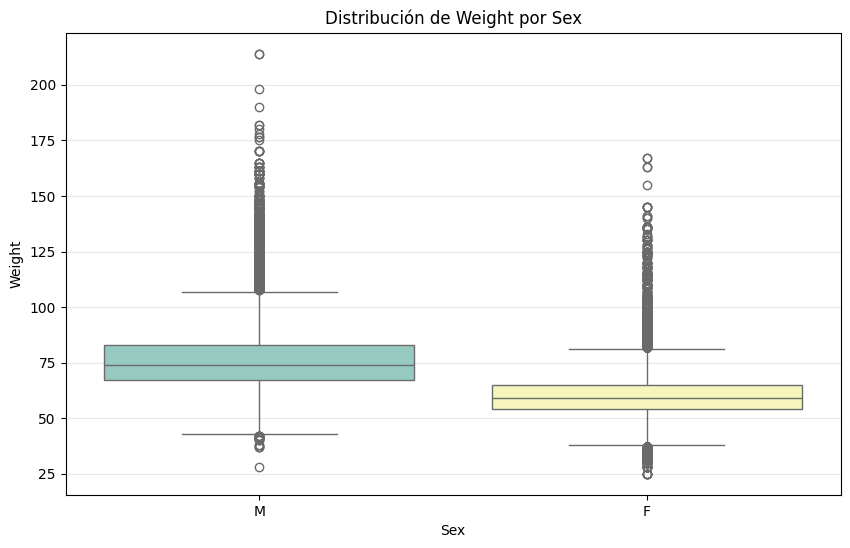

,Weight
Sex,
M,75.786320
F,60.026861


--------------------------------------------------
--- Análisis de Weight según Team ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_1264\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


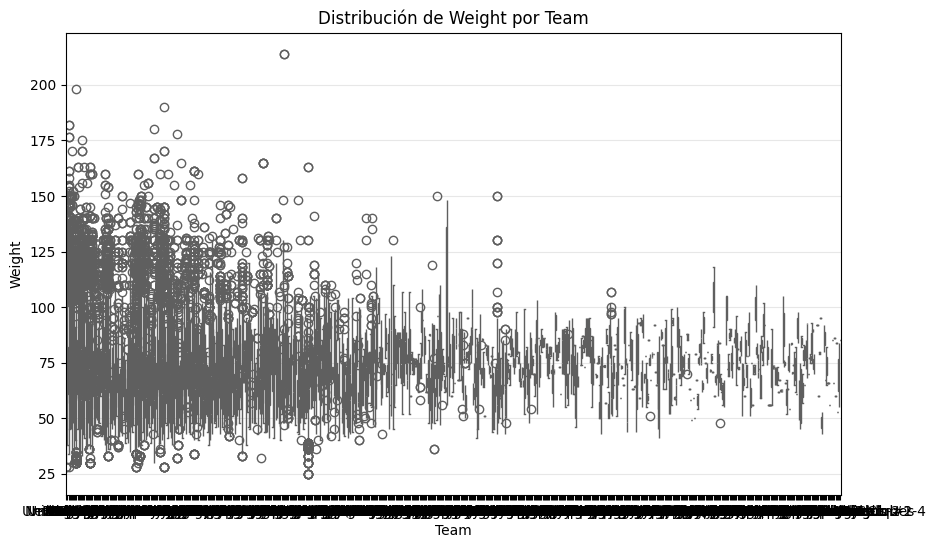

,Weight
Team,
Kathleen,104.500000
Maryke,99.500000
London City Police-1,99.285714
Puerto Rico-2,98.000000
Ireland-1,97.666667
...,...
Elvis Va,51.000000
Rambo,50.000000
Brentina,49.000000


--------------------------------------------------
--- Análisis de Weight según Season ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_1264\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


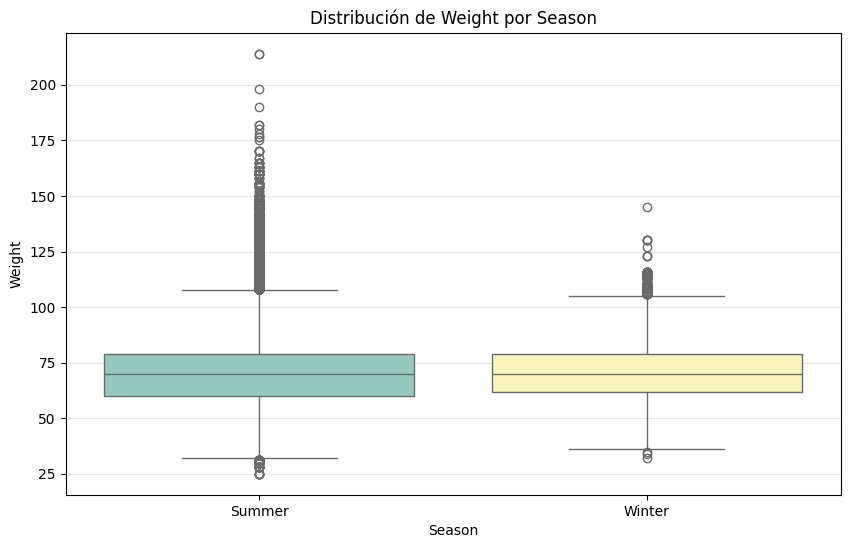

,Weight
Season,
Winter,70.753461
Summer,70.700681


--------------------------------------------------
--- Análisis de Weight según City ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_1264\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


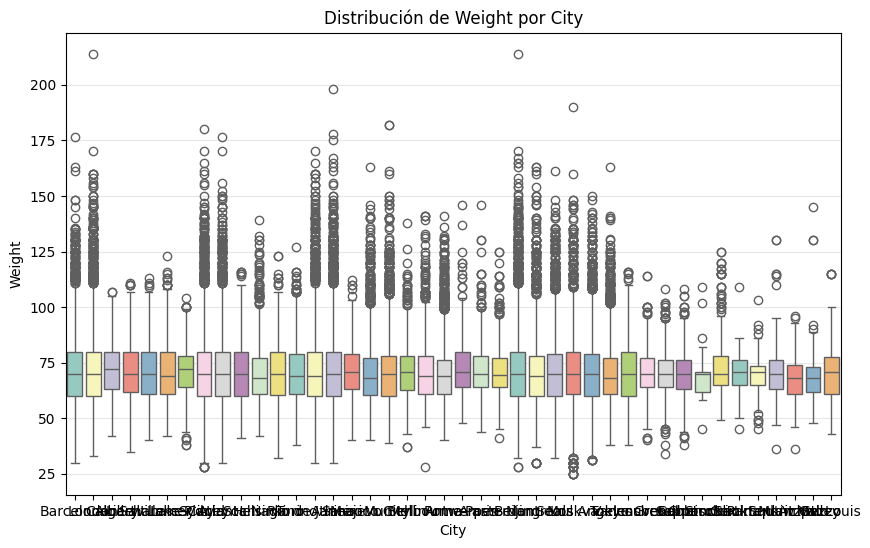

,Weight
City,
Antwerpen,73.025974
Stockholm,72.645022
St. Louis,72.521739
Paris,72.008876
Calgary,71.985360
Berlin,71.659292
London,71.504716
Beijing,71.401787
Athina,71.361349


--------------------------------------------------
--- Análisis de Weight según Sport ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_1264\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


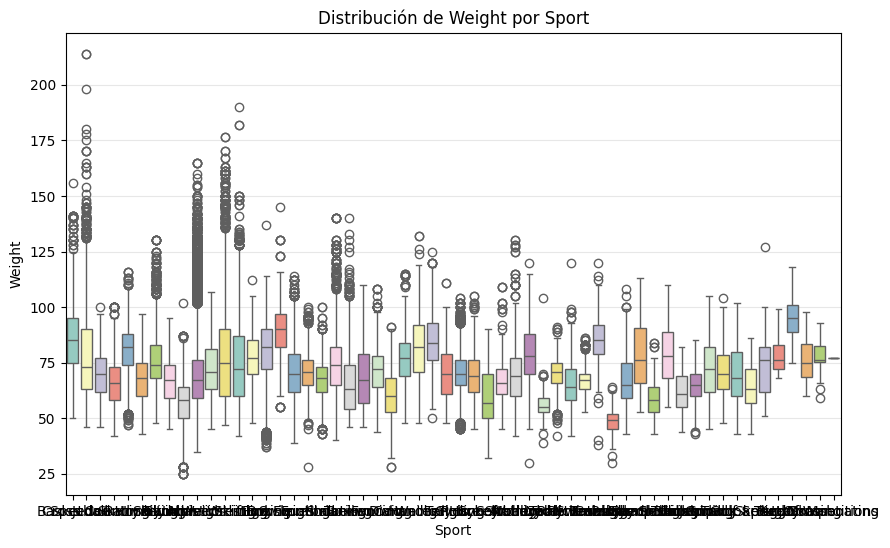

,Weight
Sport,
Tug-Of-War,95.787234
Bobsleigh,89.268464
Basketball,85.786379
Baseball,85.710808
Water Polo,84.569270
Handball,81.499849
Ice Hockey,80.812857
Rowing,80.063729
Beach Volleyball,79.089219


--------------------------------------------------
--- Análisis de Weight según Event ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_1264\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


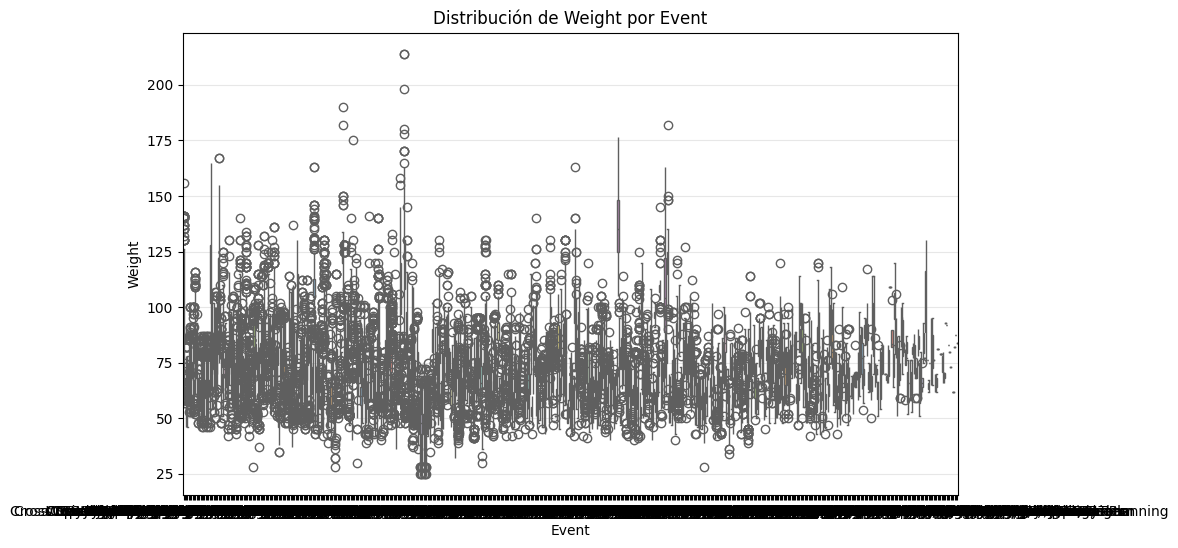

,Weight
Event,
Weightlifting Men's Super-Heavyweight,135.538265
"Wrestling Men's Super-Heavyweight, Greco-Roman",122.161290
Judo Men's Heavyweight,120.314145
"Wrestling Men's Super-Heavyweight, Freestyle",118.756614
Athletics Men's Shot Put,115.342014
...,...
Gymnastics Women's Floor Exercise,47.873572
Gymnastics Women's Uneven Bars,47.798485
Gymnastics Women's Individual All-Around,47.707925


--------------------------------------------------
--- Análisis de Weight según Medal ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_1264\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


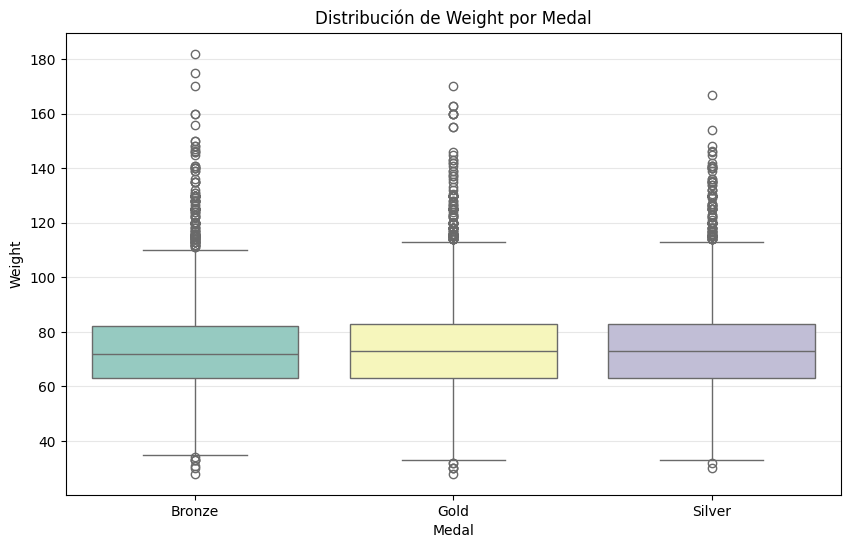

,Weight
Medal,
Gold,74.173656
Silver,73.647997
Bronze,73.481959


--------------------------------------------------


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_vars = df.select_dtypes(include=['object']).columns.tolist()
for var in cat_vars:
    print(f"--- Análisis de Weight según {var} ---")
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=var, y='Weight', palette='Set3')
    plt.title(f'Distribución de Weight por {var}')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    # Mostramos la media de peso por categoría para confirmar
    display(df.groupby(var)['Weight'].mean().to_frame().sort_values(by='Weight', ascending=False))
    print("-" * 50)

#### <span style="color:green"> Variables que no deberian incluirse en la matriz de caracteristicas, segun los boxplots, no utilizariamos: Medal, Season y City

#### <span style="color:green"> Qué tipo de procesamiento debería recibir cada una de las variables categóricas, según su tipo y cardinalidad:

#### <span style="color:green"> OneHotEncoder con sparse_output=False y drop='first' : Season, City y Sport

#### <span style="color:green"> OneHotEncoder con if binary:  Sex

#### <span style="color:green"> OrdinalEncoder: Medal
#### <span style="color:green"> OneHotEncoder con min frequency o con max categories:  Team y Event

#### <span style="color:green"> Aunque en la matriz de caracteristicas solo estaran Sport, Sex, Team y Event, por lo cual es la unica que se procesa.





## Análisis exploratorio de variables cuantitativas o numéricas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.
- Indique qué tipo de procesamiento debería recibir cada una de las variables numéricas, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

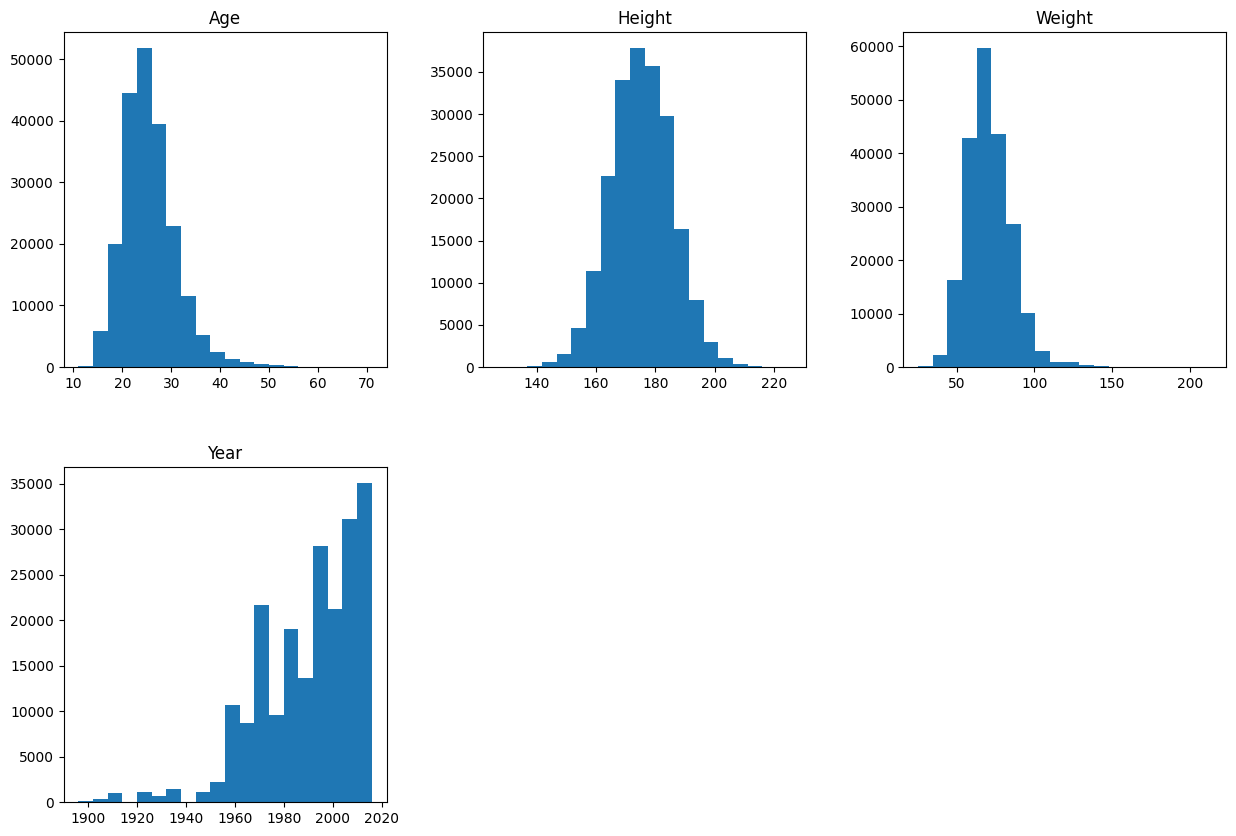

In [18]:
df.select_dtypes('number').hist(bins=20, figsize=(15,10), grid=False, layout=(2,3));

#### <span style="color:green"> Height es una variable aproximadamente normal, las otras tienen un sesgo muy marcado entonces no.

Age          Axes(0.125,0.53;0.227941x0.35)
Height    Axes(0.398529,0.53;0.227941x0.35)
Weight    Axes(0.672059,0.53;0.227941x0.35)
Year         Axes(0.125,0.11;0.227941x0.35)
dtype: object

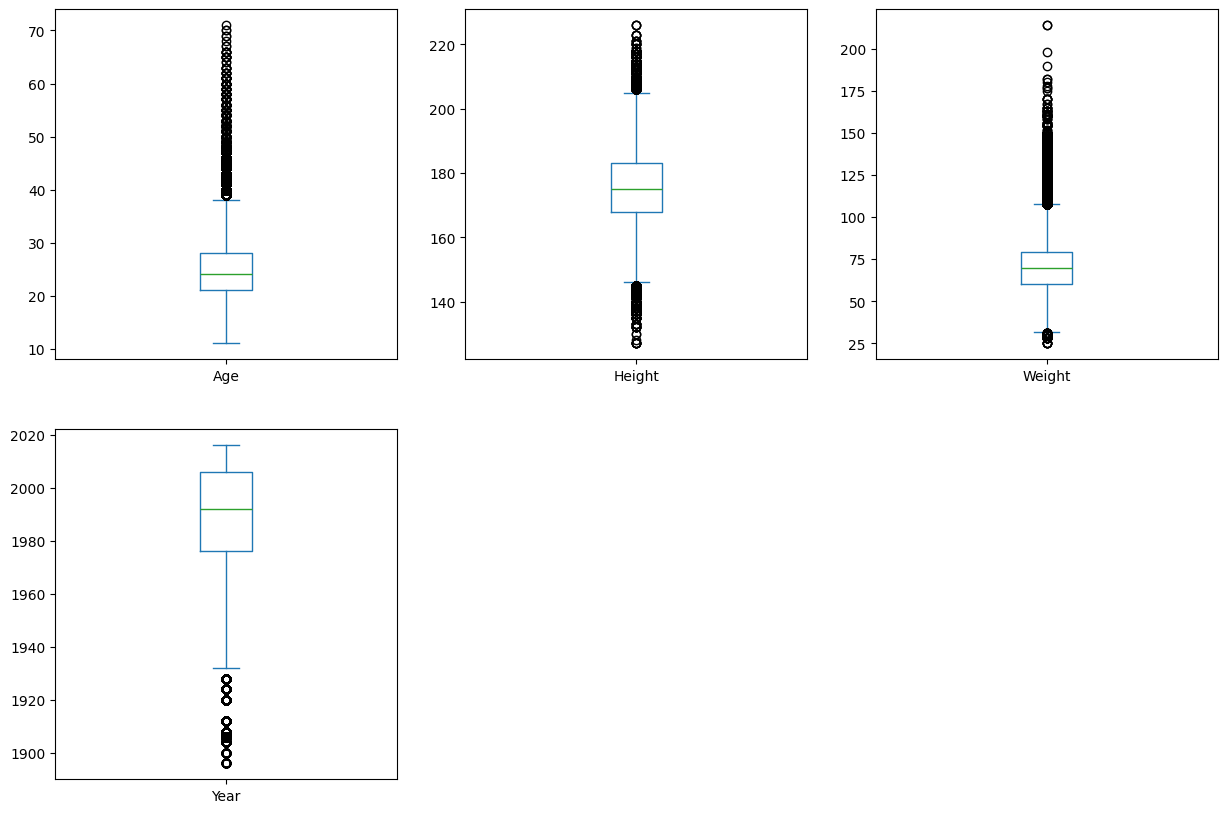

In [19]:
df.select_dtypes('number').plot(
    kind='box',
    subplots=True,
    layout=(int(len(df.select_dtypes('number').columns)/3)+1, 3),  # organiza en filas y 3 columnas
    figsize=(15, 10),
    grid=False
)

#### <span style="color:green">  Tienen datos atipicos, Height un poco por ambos lados, Age tiene mucha por la parte superior al igual que weight y year tiene por la parte inferior unicamente

In [20]:
df.select_dtypes('number').corr()


,Age,Height,Weight,Year
Age,1.000000,0.140555,0.212139,0.085184
Height,0.140555,1.000000,0.791385,0.049126
Weight,0.212139,0.791385,1.000000,0.018994
Year,0.085184,0.049126,0.018994,1.000000


<Axes: >

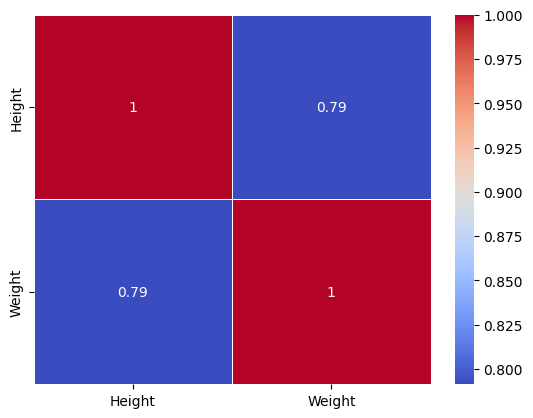

In [32]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm', linewidths=0.5)

#### <span style="color:green">  Height es buena predictora de Weight segun la correlacion de resto, las variables Age y Year no deberian de estar en la matriz de caracteristicas

#### <span style="color:green">- Indique qué tipo de procesamiento debería recibir cada una de las variables numéricas, según su distribución y la presencia de valores atípicos:

#### <span style="color:green"> Height, la cual es una variable normal, por ende se procesa con un StandardScaler()

#### <span style="color:green"> Las otras tienen sesgos muy grandes, por ende se procesa con un PowerTransformer()

#### <span style="color:green"> Aunque en la matriz de caracteristicas solo estara Height, por lo cual es la unica que se procesa.


## Procesamiento de las características y entrenamiento del modelo

- Escoja un modelo de árbol de decisión que prediga la variable **Weight**, teniendo en cuenta que es numérica continua.
- Extraiga la matriz de características y el vector objetivo de su dataframe, a partir de los análisis previos.
- Parta los datos en subconjuntos de entrenamiento y de prueba.
- Procese las características del modelo usando `ColumnTransformer`.
- Entrene el modelo.
- Reporten los **scores** de entrenamiento y de prueba.
- Reporten el listado completo de características con las que fue entrenado el modelo después del procesamiento realizado.

#### <span style="color:green">  Escojo el arbol de decision DecisionTreeRegressor ya que Weight es numerica continua.

#### <span style="color:green"> Primero hago la matriz de caracteristicas con lo hecho en los analisis previos (elimino todas las que no sirven segun los analisis anteriores)


In [33]:
df = df.drop(columns=['Age', 'Medal', 'Year', 'Season', 'City'])
df.info()


KeyError: "['Age', 'Medal', 'Year', 'Season', 'City'] not found in axis"

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(['Weight'], axis=1)
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')


Tamaño del conjunto de entrenamiento es: (144918, 5)
Tamaño del conjunto de prueba es: (62108, 5)


In [24]:
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

ss = StandardScaler() 
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') 

oheCityCardinalidadAlta = OneHotEncoder(
    sparse_output=False,
    max_categories=6,
    handle_unknown='ignore'
)

oheNominalNormal = OneHotEncoder(
    sparse_output=False,
    drop='first'
    )


In [26]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num_prep', ss, ['Height' ]),
    ('cod_binary', ohe, ['Sex']),
    ('cod_cardinalidad', oheCityCardinalidadAlta, ['Team', 'Event']),
    ('cod_nominal', oheNominalNormal, ['Sport'])

    ], remainder='drop') 

In [27]:
preprocessor

,transformers,"[('num_prep', ...), ('cod_binary', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [28]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [29]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=1
    )

tree.fit(X_train_prep, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
print(f'Accuracy en el conjunto de entrenamiento: {tree.score(X_train_prep, y_train)}')
print(f'Accuracy en el conjunto de prueba: {tree.score(X_test_prep, y_test)}')

Accuracy en el conjunto de entrenamiento: 0.6737280667390295
Accuracy en el conjunto de prueba: 0.6685651890164381


In [31]:
print(preprocessor.get_feature_names_out())

['num_prep__Height' 'cod_binary__Sex_M' 'cod_cardinalidad__Team_Canada'
 'cod_cardinalidad__Team_France' 'cod_cardinalidad__Team_Great Britain'
 'cod_cardinalidad__Team_Italy' 'cod_cardinalidad__Team_United States'
 'cod_cardinalidad__Team_infrequent_sklearn'
 "cod_cardinalidad__Event_Basketball Men's Basketball"
 "cod_cardinalidad__Event_Football Men's Football"
 "cod_cardinalidad__Event_Hockey Men's Hockey"
 "cod_cardinalidad__Event_Ice Hockey Men's Ice Hockey"
 "cod_cardinalidad__Event_Water Polo Men's Water Polo"
 'cod_cardinalidad__Event_infrequent_sklearn' 'cod_nominal__Sport_Archery'
 'cod_nominal__Sport_Art Competitions' 'cod_nominal__Sport_Athletics'
 'cod_nominal__Sport_Badminton' 'cod_nominal__Sport_Baseball'
 'cod_nominal__Sport_Basketball' 'cod_nominal__Sport_Beach Volleyball'
 'cod_nominal__Sport_Biathlon' 'cod_nominal__Sport_Bobsleigh'
 'cod_nominal__Sport_Boxing' 'cod_nominal__Sport_Canoeing'
 'cod_nominal__Sport_Cross Country Skiing' 'cod_nominal__Sport_Curling'
 'cod_